# GMU vs PEP725 cherry datasets — overlap audit

Checks whether the same cherry tree (same location, same year) is recorded
in both **GMU Cherry** and **PEP725 Cherry**, which would mean the same
underlying observation appears under two different target labels
(GMU's `gmu_x` vs PEP725's `BBCH_60`).

The prime suspect is **Switzerland**: GMU Switzerland contains *Prunus
avium* (gmu_1) from the MeteoSwiss phenology network, and PEP725 also
covers *Prunus avium* in Central Europe, so spatial overlap is plausible.
GMU Japan / S. Korea report *Prunus yedoensis*, so matches there would be
cross-species.

**Plan**
1. Load GMU + PEP725 cherry observations (no weather download)
2. Nearest-neighbour spatial match (haversine) — find station pairs within N km
3. Temporal match — among paired stations, find shared observation years
4. Label comparison — for each shared (pair, year), compare the two DOYs
5. Summary table + verdict checklist

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pysephone.constants import KEY_LAT, KEY_LON
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar

GMU_KEYS = {
    'GMU_Cherry_Japan':       'gmu_0',
    'GMU_Cherry_Switzerland': 'gmu_1',
    'GMU_Cherry_South_Korea': 'gmu_2',
}
PEP_KEY     = 'PEP725_Cherry'
PEP_OBS_KEY = 'BBCH_60'

MATCH_RADIUS_KM = 5.0   # stations within this distance are considered same site

## 1. Load observations (no weather)

In [2]:
cal = Calendar()

def load_records(key, obs_key):
    ds = Dataset.load(key, calendar=cal, feature_providers=[])
    rows = []
    for s in ds.iter_items():
        obs = s.get('observations', {})
        if obs_key not in obs:
            continue
        date = np.datetime64(obs[obs_key], 'D')
        doy  = int((date - np.datetime64(f"{s['year']}-01-01", 'D')) / np.timedelta64(1, 'D')) + 1
        rows.append({
            'src':     s['src'],
            'loc_id':  s['loc_id'],
            'year':    s['year'],
            'lat':     float(s[KEY_LAT]),
            'lon':     float(s[KEY_LON]),
            'date':    date,
            'doy':     doy,
            'obs_key': obs_key,
        })
    return pd.DataFrame(rows)


gmu_frames = {}
for key, obs_key in GMU_KEYS.items():
    try:
        gmu_frames[key] = load_records(key, obs_key)
    except Exception as e:
        print(f'[skip] {key}: {e}')

pep_df = load_records(PEP_KEY, PEP_OBS_KEY)

print(f"PEP725_Cherry: {len(pep_df)} obs, {pep_df['loc_id'].nunique()} stations, "
      f"{pep_df['year'].min()}\u2013{pep_df['year'].max()}")
for k, df in gmu_frames.items():
    print(f"{k:26s}: {len(df):6d} obs, {df['loc_id'].nunique()} stations, "
          f"{df['year'].min()}\u2013{df['year'].max()}")

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 16355.73it/s]


PEP725_Cherry: 7565 obs, 1095 stations, 1986–2016
GMU_Cherry_Japan          :   2410 obs, 82 stations, 1986–2021
GMU_Cherry_Switzerland    :   1080 obs, 67 stations, 1986–2021
GMU_Cherry_South_Korea    :    505 obs, 52 stations, 1986–2020


## 2. Spatial overlap — pair stations within `MATCH_RADIUS_KM`

Haversine distance between every GMU station and every PEP725 station. A
GMU station is "matched" if its **nearest** PEP725 station is ≤
`MATCH_RADIUS_KM`.

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    dlat = lat2r - lat1r
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def station_table(df):
    return df.groupby('loc_id').agg(
        lat=('lat', 'first'), lon=('lon', 'first'),
        years=('year', lambda s: set(s))
    ).reset_index()


pep_stations = station_table(pep_df)

overlap_pairs = {}
for gkey, gdf in gmu_frames.items():
    gmu_stations = station_table(gdf)
    if gmu_stations.empty or pep_stations.empty:
        continue
    g_lat = gmu_stations['lat'].values[:, None]
    g_lon = gmu_stations['lon'].values[:, None]
    p_lat = pep_stations['lat'].values[None, :]
    p_lon = pep_stations['lon'].values[None, :]
    D = haversine_km(g_lat, g_lon, p_lat, p_lon)

    nearest   = D.argmin(axis=1)
    nearest_d = D[np.arange(len(gmu_stations)), nearest]

    matched = []
    for i, (pj, dij) in enumerate(zip(nearest, nearest_d)):
        if dij <= MATCH_RADIUS_KM:
            matched.append({
                'gmu_loc_id': gmu_stations.loc[i, 'loc_id'],
                'pep_loc_id': pep_stations.loc[pj, 'loc_id'],
                'gmu_lat':    float(gmu_stations.loc[i, 'lat']),
                'gmu_lon':    float(gmu_stations.loc[i, 'lon']),
                'pep_lat':    float(pep_stations.loc[pj, 'lat']),
                'pep_lon':    float(pep_stations.loc[pj, 'lon']),
                'dist_km':    float(dij),
                'gmu_years':  gmu_stations.loc[i, 'years'],
                'pep_years':  pep_stations.loc[pj, 'years'],
            })
    overlap_pairs[gkey] = pd.DataFrame(matched)
    print(f'{gkey}: {len(gmu_stations)} stations \u2192 '
          f'{len(matched)} matched (\u2264{MATCH_RADIUS_KM} km), '
          f'NN-distance median {np.median(nearest_d):.1f} km')

GMU_Cherry_Japan: 82 stations → 0 matched (≤5.0 km), NN-distance median 7889.8 km
GMU_Cherry_Switzerland: 67 stations → 34 matched (≤5.0 km), NN-distance median 4.5 km
GMU_Cherry_South_Korea: 52 stations → 0 matched (≤5.0 km), NN-distance median 7427.0 km


## 3. Pair map

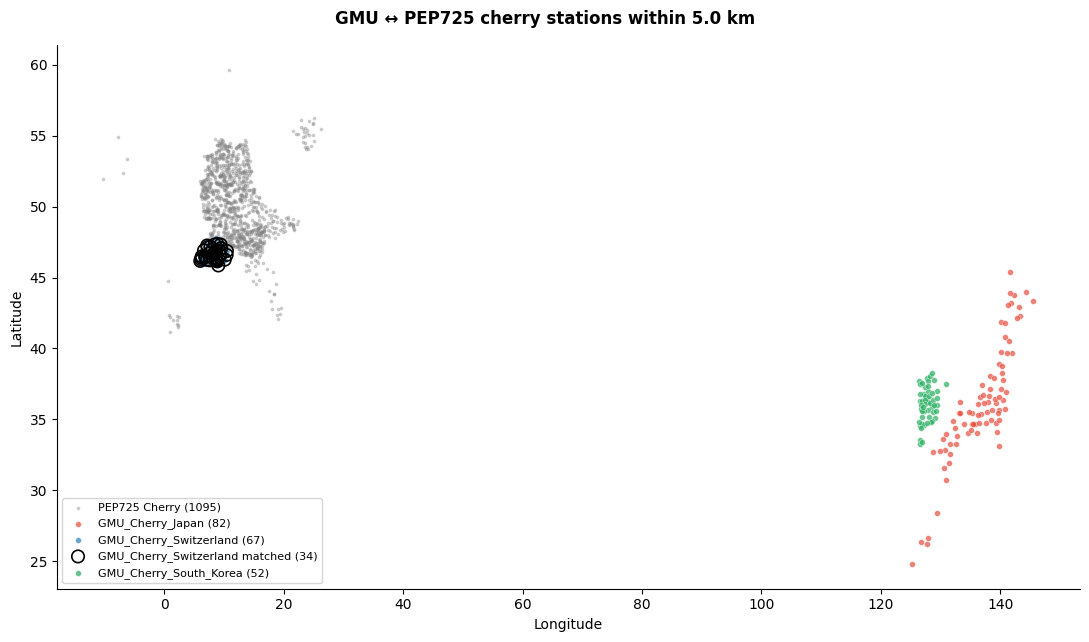

In [4]:
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.suptitle(f'GMU \u2194 PEP725 cherry stations within {MATCH_RADIUS_KM} km',
             fontsize=12, fontweight='bold')

pep_unique = pep_df[['lat', 'lon']].drop_duplicates()
ax.scatter(pep_unique['lon'], pep_unique['lat'], s=3, alpha=0.3,
           color='grey', label=f"PEP725 Cherry ({pep_df['loc_id'].nunique()})")

color_map = {
    'GMU_Cherry_Japan':       '#e74c3c',
    'GMU_Cherry_Switzerland': '#2980b9',
    'GMU_Cherry_South_Korea': '#27ae60',
}
for gkey, pairs in overlap_pairs.items():
    gdf = gmu_frames[gkey]
    gmu_unique = gdf[['lat', 'lon']].drop_duplicates()
    ax.scatter(gmu_unique['lon'], gmu_unique['lat'],
               s=18, alpha=0.7, color=color_map[gkey],
               edgecolors='white', linewidths=0.4,
               label=f"{gkey} ({gdf['loc_id'].nunique()})")
    if not pairs.empty:
        for _, r in pairs.iterrows():
            ax.plot([r.gmu_lon, r.pep_lon], [r.gmu_lat, r.pep_lat],
                    color='black', lw=0.8, alpha=0.7)
        ax.scatter(pairs['gmu_lon'], pairs['gmu_lat'], s=80,
                   facecolors='none', edgecolors='black', linewidths=1.2,
                   label=f'{gkey} matched ({len(pairs)})')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(fontsize=8, loc='lower left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Temporal overlap — shared (pair, year) observations

For each matched `(gmu_loc, pep_loc)` pair, find years that appear in both
datasets and record the two DOYs.

In [5]:
def expand_pair_years(pairs, gdf, pdf, gmu_obs_key):
    rows = []
    for _, r in pairs.iterrows():
        shared = r.gmu_years & r.pep_years
        if not shared:
            continue
        g_sub = gdf[(gdf['loc_id'] == r.gmu_loc_id) & gdf['year'].isin(shared)]
        p_sub = pdf[(pdf['loc_id'] == r.pep_loc_id) & pdf['year'].isin(shared)]
        g_doy = g_sub.groupby('year')['doy'].median()
        p_doy = p_sub.groupby('year')['doy'].median()
        for yr in sorted(shared):
            if yr in g_doy.index and yr in p_doy.index:
                rows.append({
                    'gmu_loc_id':  r.gmu_loc_id,
                    'pep_loc_id':  r.pep_loc_id,
                    'dist_km':     r.dist_km,
                    'year':        yr,
                    'gmu_doy':     int(g_doy[yr]),
                    'pep_doy':     int(p_doy[yr]),
                    'delta_doy':   int(g_doy[yr]) - int(p_doy[yr]),
                    'gmu_obs_key': gmu_obs_key,
                })
    return pd.DataFrame(rows)


pairings = {}
for gkey, pairs in overlap_pairs.items():
    if pairs.empty: continue
    pairings[gkey] = expand_pair_years(pairs, gmu_frames[gkey], pep_df, GMU_KEYS[gkey])
    print(f'{gkey}: {len(pairings[gkey])} shared (pair, year) observations')

GMU_Cherry_Switzerland: 73 shared (pair, year) observations


## 5. Label comparison — GMU vs PEP725 DOY

If the two datasets point to the same tree, the DOY difference should be
**small and tightly clustered** around a systematic offset reflecting the
definitional difference between the target labels. Large or structureless
spread means the pairing is spurious (co-located stations, different trees).

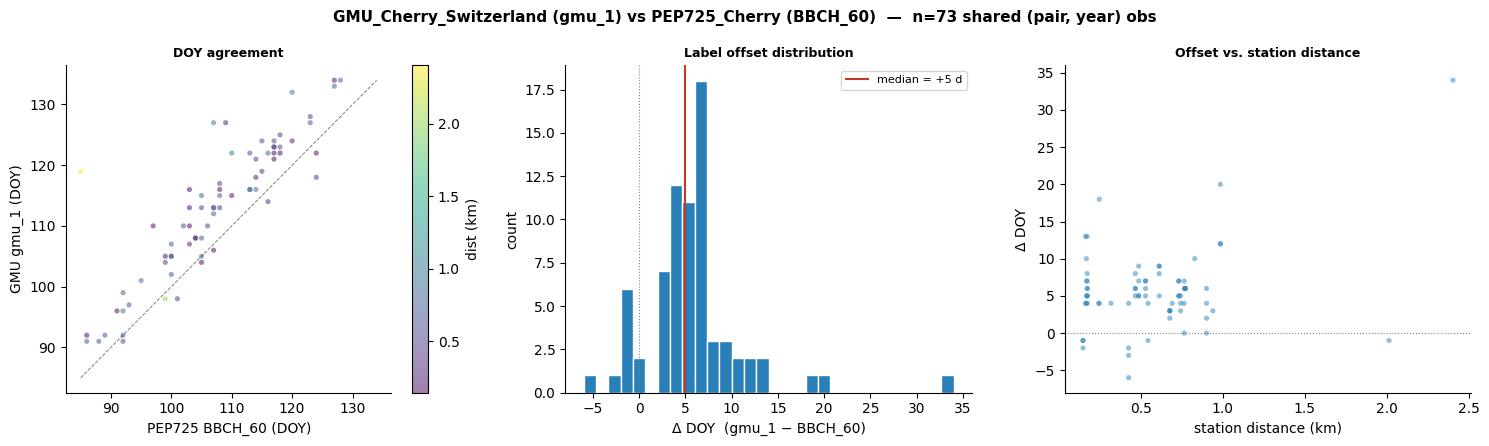

In [6]:
def plot_label_comparison(gkey, df):
    if df.empty:
        print(f'{gkey}: no shared (pair, year) observations'); return
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(
        f'{gkey} ({GMU_KEYS[gkey]}) vs PEP725_Cherry (BBCH_60)  \u2014  '
        f'n={len(df)} shared (pair, year) obs',
        fontsize=11, fontweight='bold'
    )

    ax = axes[0]
    sc = ax.scatter(df['pep_doy'], df['gmu_doy'], s=14, alpha=0.5,
                    c=df['dist_km'], cmap='viridis', edgecolors='none')
    lo = min(df['pep_doy'].min(), df['gmu_doy'].min())
    hi = max(df['pep_doy'].max(), df['gmu_doy'].max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7, alpha=0.5)
    plt.colorbar(sc, ax=ax, label='dist (km)')
    ax.set_xlabel('PEP725 BBCH_60 (DOY)'); ax.set_ylabel(f'GMU {GMU_KEYS[gkey]} (DOY)')
    ax.set_title('DOY agreement', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[1]
    ax.hist(df['delta_doy'], bins=30, color='#2980b9', edgecolor='white')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    med = df['delta_doy'].median()
    ax.axvline(med, color='#c0392b', lw=1.5, label=f'median = {med:+.0f} d')
    ax.set_xlabel(f"\u0394 DOY  ({GMU_KEYS[gkey]} \u2212 BBCH_60)"); ax.set_ylabel('count')
    ax.set_title('Label offset distribution', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[2]
    ax.scatter(df['dist_km'], df['delta_doy'], s=14, alpha=0.5,
               color='#2980b9', edgecolors='none')
    ax.axhline(0, color='grey', lw=0.8, ls=':')
    ax.set_xlabel('station distance (km)'); ax.set_ylabel('\u0394 DOY')
    ax.set_title('Offset vs. station distance', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.tight_layout(); plt.show()


for gkey, df in pairings.items():
    plot_label_comparison(gkey, df)

## 6. Summary table

In [7]:
rows = []
for gkey, pairs in overlap_pairs.items():
    dfp = pairings.get(gkey, pd.DataFrame())
    rows.append({
        'GMU dataset':           gkey,
        'GMU stations':          gmu_frames[gkey]['loc_id'].nunique(),
        'matched_km':            len(pairs),
        'shared (pair, year)':   len(dfp),
        'median \u0394 DOY':     (f"{dfp['delta_doy'].median():+.1f}" if len(dfp) else '\u2014'),
        'std \u0394 DOY':        (f"{dfp['delta_doy'].std():.1f}"    if len(dfp) else '\u2014'),
        '|\u0394 DOY| < 7 d':    (f"{(dfp['delta_doy'].abs() < 7).sum()}/{len(dfp)}" if len(dfp) else '\u2014'),
    })
summary = pd.DataFrame(rows).set_index('GMU dataset')
summary.columns = [c.replace('matched_km', f'matched \u2264{MATCH_RADIUS_KM:.0f} km')
                   for c in summary.columns]
display(summary)

,GMU stations,matched ≤5 km,"shared (pair, year)",median Δ DOY,std Δ DOY,|Δ DOY| < 7 d
GMU dataset,,,,,,
GMU_Cherry_Japan,82,0,0,—,—,—
GMU_Cherry_Switzerland,67,34,73,+5.0,5.4,50/73
GMU_Cherry_South_Korea,52,0,0,—,—,—


## 7. Verdict checklist

- **No matched stations** → no duplication risk; the datasets share no trees.
- **Matched stations, tight Δ-DOY cluster near a small systematic offset** →
  strong evidence the *same tree* is recorded twice under two labels. Handle
  carefully in joint training / evaluation (could leak between train and test).
- **Matched stations, wide scatter / centred on zero with large std** → same
  grid cell but plausibly *different trees* (cultivars, microclimate).
  Overlap is at the *grid* level, not the *individual-tree* level.
- **Species mismatch** — GMU Japan / S. Korea are *P. yedoensis*, PEP725 is
  *P. avium*: any matches there are almost certainly co-located but *not* the
  same tree, and the Δ-DOY distribution will likely be broad.